# NYC Rideshare: Impact of Congestion Pricing
## A Quasi-Experimental Before/After Analysis

**Author:** Amontay Welch  
**Date:** March 2026  
**Data Source:** NYC Taxi & Limousine Commission (TLC) High Volume FHV Trip Records  
**Analysis Period:** Oct–Dec 2024 (Before) vs Feb–Apr 2025 (After)  

---

### Overview
On January 5, 2025, New York City implemented congestion pricing, charging a $1.50 fee on rideshare trips entering the Central Business District below 60th Street. This analysis examines how that policy change affected rideshare behavior across trip volume, fares,
duration, tipping, and geographic patterns using 120M+ real trips.

### Key Questions
- Did congestion pricing reduce rideshare demand into Manhattan?
- Which neighborhoods and boroughs were most affected?
- Did trips get faster after implementation?
- How did rider behavior (tipping, shared rides) shift?

---


## **Importing Modules**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from google.cloud import bigquery

COLOR_BEFORE = '#1565C0'   # dark blue
COLOR_AFTER = '#90CAF9'    # light blue
COLOR_NEGATIVE = '#0D47A1' # deeper blue for negative changes
COLOR_POSITIVE = '#BBDEFB' # pale blue for positive/neutral

# BigQuery client
client = bigquery.Client(project='project-715687c4-6754-4729-834')

# visual style
sns.set_theme(style = 'whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully")

Libraries loaded successfully




---



## **Importing Check**

In [2]:
# testing to ensure correct number of rows were imported

test = client.query("""
    SELECT COUNT(*) AS total_trips
    FROM `project-715687c4-6754-4729-834.nyc_rideshare.rideshare_clean`
""").to_dataframe()

print(test)

   total_trips
0    120555690




---



## **SQL Query Loading**

In [3]:
# loading SQL queries into dataframes for visualizations

# overall before vs after comparison
df_overall = client.query("""
    SELECT
        period,
        COUNT(*) AS total_trips,
        ROUND(AVG(trip_miles), 2) AS avg_trip_miles,
        ROUND(AVG(trip_time / 60), 2) AS avg_trip_minutes,
        ROUND(AVG(base_passenger_fare), 2) AS avg_fare,
        ROUND(AVG(tips), 2) AS avg_tip,
        ROUND(AVG(tips / NULLIF(base_passenger_fare, 0)) * 100, 2) AS avg_tip_pct,
        ROUND(AVG(CASE WHEN shared_request_flag = 'Y' THEN 1 ELSE 0 END) * 100, 2) AS shared_ride_pct
    FROM `project-715687c4-6754-4729-834.nyc_rideshare.rideshare_clean`
    GROUP BY period
    ORDER BY period DESC
""").to_dataframe()

# Manhattan specific analysis
df_manhattan = client.query("""
    SELECT
        period,
        COUNT(*) AS total_trips,
        ROUND(AVG(base_passenger_fare), 2) AS avg_fare,
        ROUND(AVG(tips), 2) AS avg_tip,
        ROUND(AVG(trip_miles), 2) AS avg_miles,
        ROUND(AVG(trip_time / 60), 2) AS avg_minutes
    FROM `project-715687c4-6754-4729-834.nyc_rideshare.rideshare_clean`
    WHERE DOLocationID IN (
        SELECT LocationID
        FROM `project-715687c4-6754-4729-834.nyc_rideshare.taxi_zones`
        WHERE borough = 'Manhattan'
    )
    GROUP BY period
    ORDER BY period DESC
""").to_dataframe()

# borough level summary
df_borough = client.query("""
    SELECT
        z.borough,
        period,
        COUNT(*) AS total_trips,
        ROUND(AVG(base_passenger_fare), 2) AS avg_fare,
        ROUND(AVG(trip_time / 60), 2) AS avg_minutes,
        ROUND(AVG(trip_miles), 2) AS avg_miles
    FROM `project-715687c4-6754-4729-834.nyc_rideshare.rideshare_clean` AS r
    JOIN `project-715687c4-6754-4729-834.nyc_rideshare.taxi_zones` AS z
        ON r.DOLocationID = z.LocationID
    WHERE z.borough NOT IN ('N/A', 'Unknown', 'EWR')
    GROUP BY z.borough, period
    ORDER BY borough, period DESC
""").to_dataframe()

# zone change ranking
df_zones = client.query("""
    WITH before_data AS (
        SELECT
            z.zone,
            z.borough,
            COUNT(*) AS before_trips,
            ROUND(AVG(trip_time / 60), 2) AS before_minutes
        FROM `project-715687c4-6754-4729-834.nyc_rideshare.rideshare_clean` AS r
        JOIN `project-715687c4-6754-4729-834.nyc_rideshare.taxi_zones` AS z
            ON r.DOLocationID = z.LocationID
        WHERE period = 'before'
        AND z.borough NOT IN('N/A', 'Unknown', 'EWR')
        GROUP BY z.zone, z.borough
    ),
    after_data AS (
        SELECT
            z.zone,
            z.borough,
            COUNT(*) AS after_trips,
            ROUND(AVG(trip_time / 60), 2) AS after_minutes
        FROM `project-715687c4-6754-4729-834.nyc_rideshare.rideshare_clean` AS r
        JOIN `project-715687c4-6754-4729-834.nyc_rideshare.taxi_zones` AS z
            ON r.DOLocationID = z.LocationID
        WHERE period = 'after'
        AND z.borough NOT IN('N/A', 'Unknown', 'EWR')
        GROUP BY z.zone, z.borough
    )
    SELECT
        b.zone,
        b.borough,
        b.before_trips,
        a.after_trips,
        ROUND((a.after_trips - b.before_trips) / b.before_trips * 100, 2) AS trip_change_pct,
        b.before_minutes,
        a.after_minutes,
        ROUND(a.after_minutes - b.before_minutes, 2) AS minutes_change
    FROM before_data AS b
    JOIN after_data AS a ON b.zone = a.zone
    WHERE b.before_trips >= 10000
    ORDER BY trip_change_pct ASC
    LIMIT 25
""").to_dataframe()

# monthly trend
df_monthly = client.query("""
    SELECT
        FORMAT_DATE('%Y-%m', DATE(pickup_datetime)) AS month,
        period,
        COUNT(*) AS total_trips,
        ROUND(AVG(base_passenger_fare), 2) AS avg_fare,
        ROUND(AVG(trip_time / 60), 2) AS avg_minutes
    FROM `project-715687c4-6754-4729-834.nyc_rideshare.rideshare_clean`
    GROUP BY month, period
    ORDER BY month
""").to_dataframe()

# shared ride by borough
df_shared = client.query("""
    SELECT
        z.borough,
        period,
        ROUND(AVG(CASE WHEN shared_request_flag = 'Y' THEN 1 ELSE 0 END) * 100, 2) AS shared_ride_pct,
        COUNT(*) AS total_trips
    FROM `project-715687c4-6754-4729-834.nyc_rideshare.rideshare_clean` AS r
    JOIN `project-715687c4-6754-4729-834.nyc_rideshare.taxi_zones` AS z
        ON r.DOLocationID = z.LocationID
    WHERE z.borough NOT IN ('N/A', 'EWR', 'Unknown')
    GROUP BY z.borough, period
    ORDER BY borough, period DESC
""").to_dataframe()

# time of day
df_tod = client.query("""
    SELECT
        period,
        EXTRACT(HOUR FROM pickup_datetime) AS hour_of_day,
        COUNT(*) AS total_trips,
        ROUND(AVG(base_passenger_fare), 2) AS avg_fare,
        ROUND(AVG(trip_time / 60), 2) AS avg_minutes
    FROM `project-715687c4-6754-4729-834.nyc_rideshare.rideshare_clean`
    GROUP BY period, hour_of_day
    ORDER BY hour_of_day, period DESC
""").to_dataframe()

print("All datasets loaded successfully")
print(f"Overall: {df_overall.shape}")
print(f"Manhattan: {df_manhattan.shape}")
print(f"Borough: {df_borough.shape}")
print(f"Zones: {df_zones.shape}")
print(f"Monthly: {df_monthly.shape}")
print(f"Shared: {df_shared.shape}")
print(f"Time of day: {df_tod.shape}")

All datasets loaded successfully
Overall: (2, 8)
Manhattan: (2, 6)
Borough: (10, 6)
Zones: (25, 8)
Monthly: (6, 5)
Shared: (10, 4)
Time of day: (48, 5)




---



## **Overall Before vs. After Metrics**

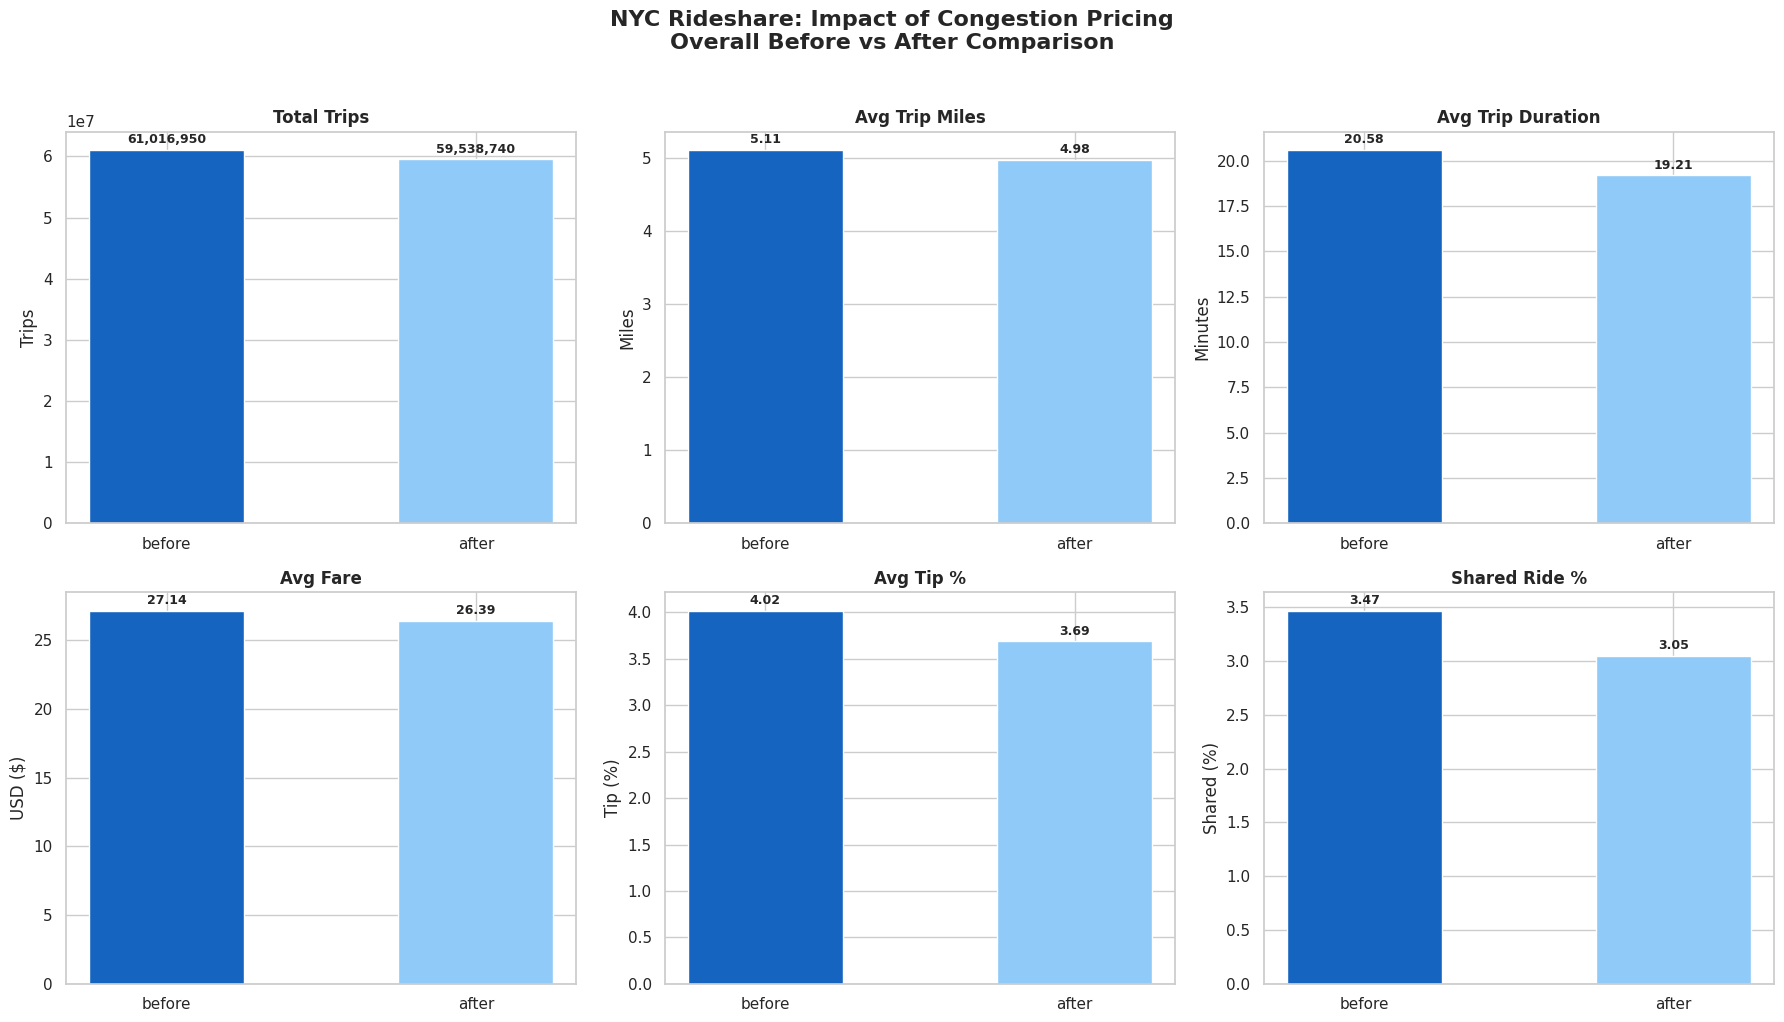

Chart saved


In [4]:
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
fig.suptitle('NYC Rideshare: Impact of Congestion Pricing\nOverall Before vs After Comparison',
             fontsize = 16, fontweight = 'bold', y = 1.02)

colors = [COLOR_BEFORE, COLOR_AFTER]
metrics = [
    ('total_trips', 'Total Trips', 'Trips'),
    ('avg_trip_miles', 'Avg Trip Miles', 'Miles'),
    ('avg_trip_minutes', 'Avg Trip Duration', 'Minutes'),
    ('avg_fare', 'Avg Fare', 'USD ($)'),
    ('avg_tip_pct', 'Avg Tip %', 'Tip (%)'),
    ('shared_ride_pct', 'Shared Ride %', 'Shared (%)')
]

for ax, (col, title, ylabel) in zip(axes.flatten(), metrics):
    bars = ax.bar(df_overall['period'], df_overall[col], color = colors, width = 0.5, edgecolor = 'white')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('')
    for bar, val in zip(bars, df_overall[col]):
        fmt = f'{val:,.0f}' if col == 'total_trips' else f'{val:.2f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.01,
               fmt, ha = 'center', va = 'bottom', fontsize = 9, fontweight = 'bold')

plt.tight_layout()
plt.savefig('overall_comparison.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print("Chart saved")

**Overall ridership decreased 2.4%** in the three months after the congestion fee implementation, suggesting modest but measurable change across the city.



---



## **Borough-Level Trip Volume**

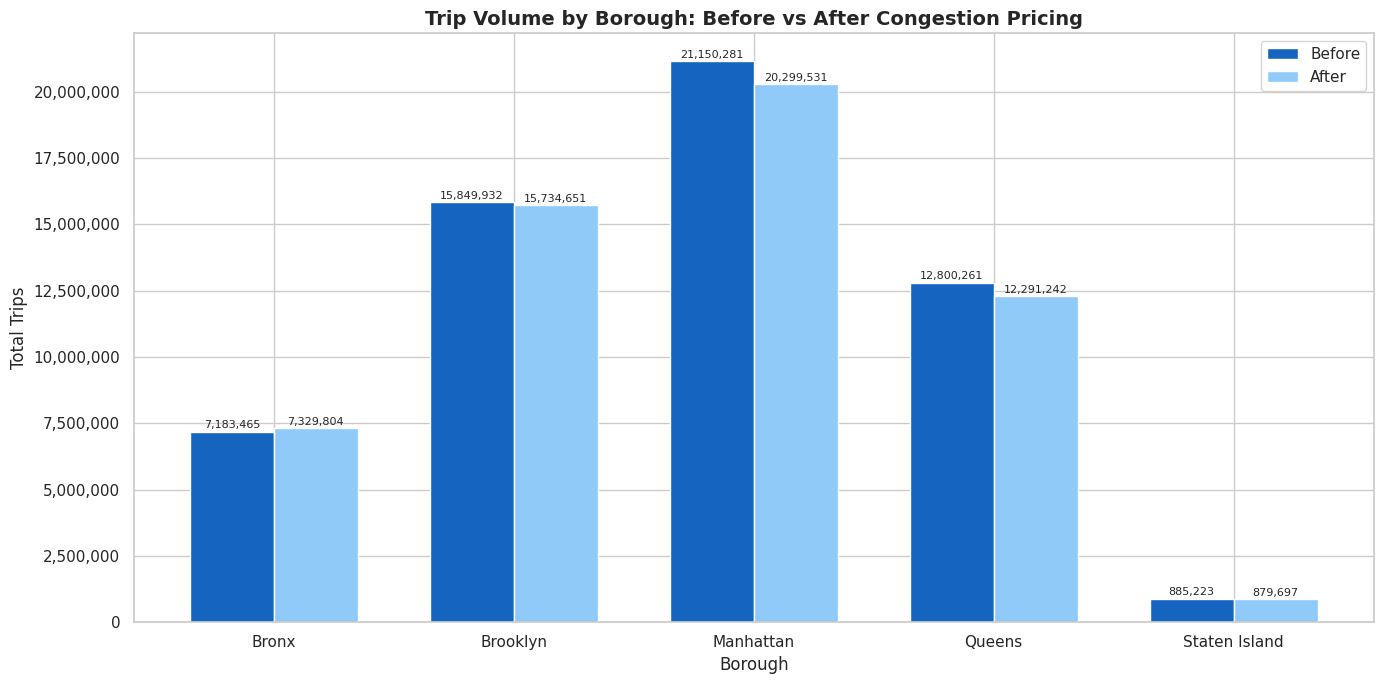

Chart saved


In [5]:
fig, ax = plt.subplots(figsize = (14, 7))

boroughs = df_borough['borough'].unique()
x = np.arange(len(boroughs))
width = 0.35

before = df_borough[df_borough['period'] == 'before'].set_index('borough')
after = df_borough[df_borough['period'] == 'after'].set_index('borough')

bars1 = ax.bar(x - width/2, before.loc[boroughs, 'total_trips'], width,
               label = 'Before', color = COLOR_BEFORE, edgecolor = 'white')
bars2 = ax.bar(x + width/2, after.loc[boroughs, 'total_trips'], width,
               label = 'After', color = COLOR_AFTER, edgecolor = 'white')

ax.set_title('Trip Volume by Borough: Before vs After Congestion Pricing',
             fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Borough')
ax.set_ylabel('Total Trips')
ax.set_xticks(x)
ax.set_xticklabels(boroughs)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
           f'{bar.get_height():,.0f}', ha = 'center', va = 'bottom', fontsize = 8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
           f'{bar.get_height():,.0f}', ha = 'center', va = 'bottom', fontsize = 8)

plt.tight_layout()
plt.savefig('borough_volume.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print("Chart saved")

Manhattan saw the **sharpest decline at 4%, double the overall network rate**, while Brooklyn, Queens, and Staten Island remained largely flat.

Notably, the Bronx saw a **2% increase in trip volume** after congestion pricing, suggesting possible trip displacement, where riders previously traveling through Manhattan are now routing to or through outer borough destinations to avoid the congestion fee. This will be further analyzed in Part 2 of the project.





---



## **Borough Trip Duration Change**

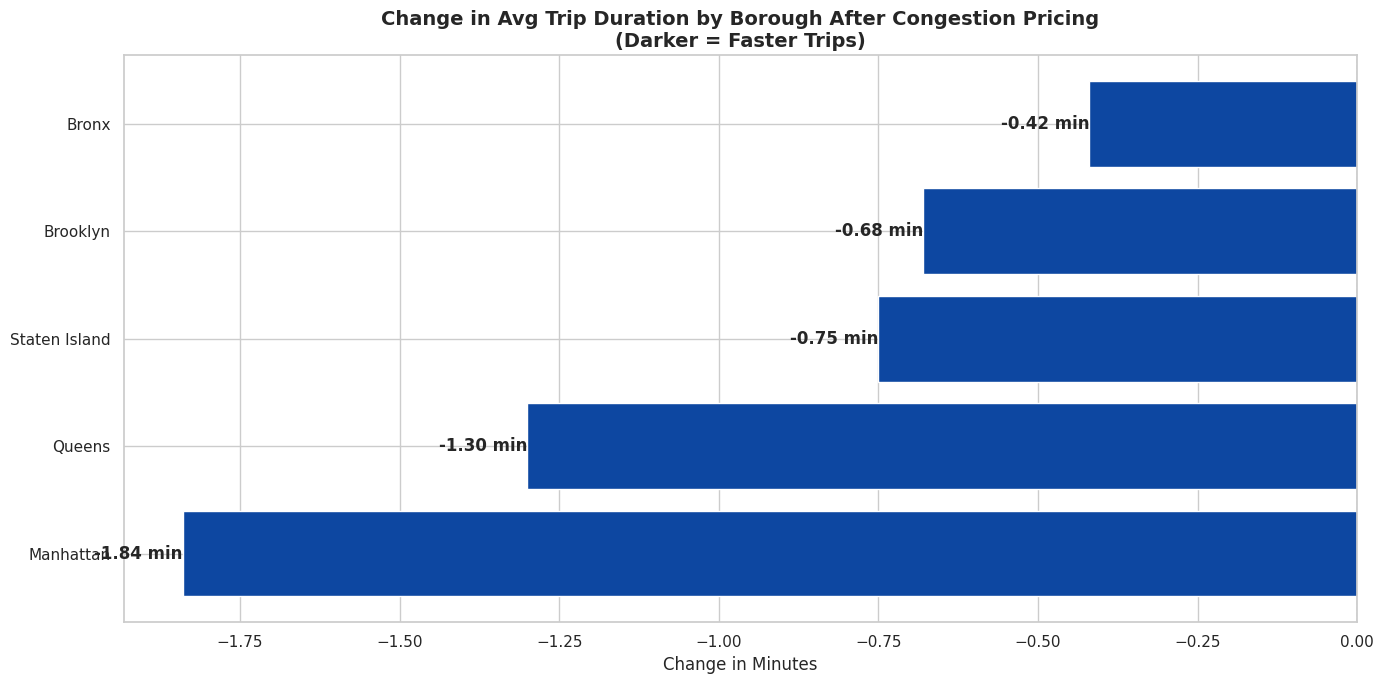

Chart saved


In [6]:
fig, ax = plt.subplots(figsize = (14, 7))

before_mins = df_borough[df_borough['period'] == 'before'].set_index('borough')['avg_minutes']
after_mins = df_borough[df_borough['period'] == 'after'].set_index('borough')['avg_minutes']
duration_change = (after_mins - before_mins).sort_values()

colors_change = [COLOR_NEGATIVE if x < 0 else COLOR_POSITIVE for x in duration_change]
bars = ax.barh(duration_change.index, duration_change.values, color = colors_change, edgecolor = 'white')

ax.set_title('Change in Avg Trip Duration by Borough After Congestion Pricing\n(Darker = Faster Trips)',
             fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Change in Minutes')
ax.axvline(x = 0, color = 'black', linewidth = 0.8, linestyle = '--')

for bar, val in zip(bars, duration_change.values):
    ax.text(val if val < 0 else val + 0.05, bar.get_y() + bar.get_height()/2,
           f'{val:.2f} min', ha = 'right' if val < 0 else 'left', va = 'center',
           fontweight = 'bold')

plt.tight_layout()
plt.savefig('borough_duration_change.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print("Chart saved")

Every borough saw faster trip times after the fee was added, with Manhattan seeing a **near 2 minute change** in rideshare trip durations, the largest change out of all boroughs. The across-the-board reduction signals that the policy had a broader effect beyond the congestion zone.



---



## **Monthly Trip Volume Trend**

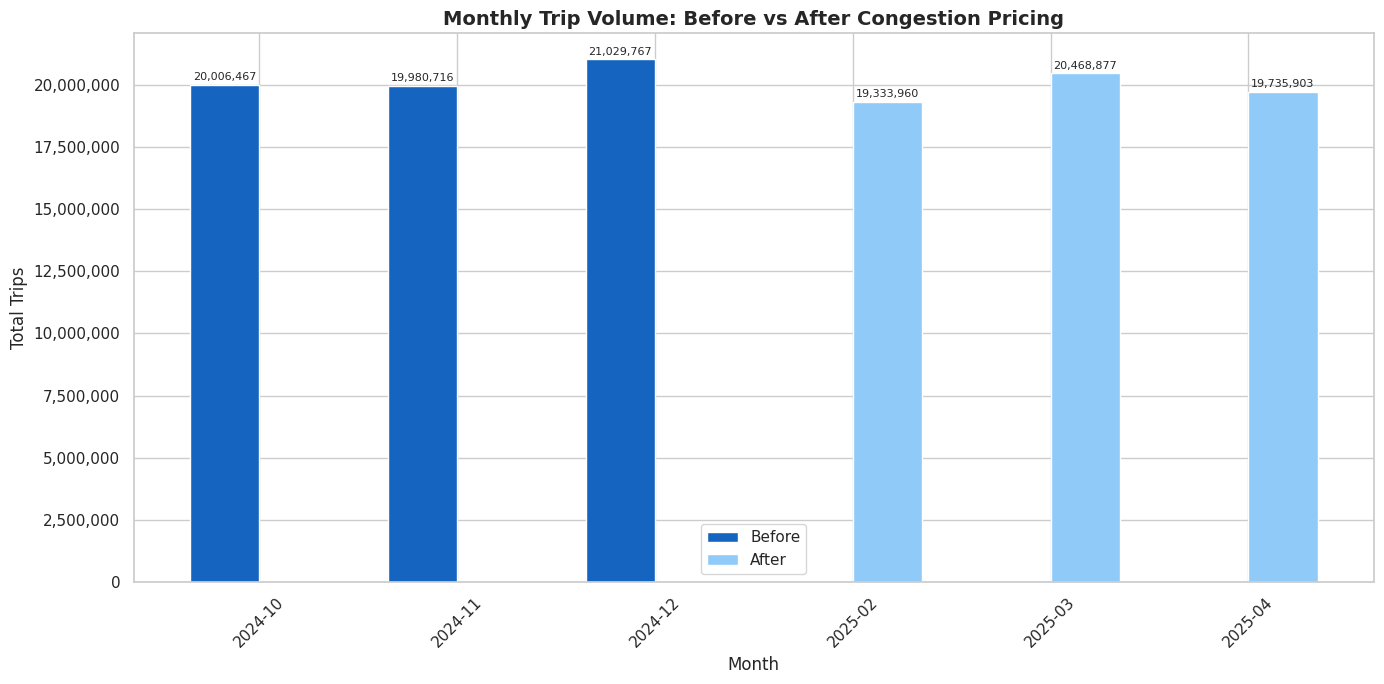

Chart saved


In [7]:
fig, ax = plt.subplots(figsize = (14, 7))

df_monthly_sorted = df_monthly.sort_values('month')
months = df_monthly_sorted['month'].unique()
x = np.arange(len(months))
width = 0.35

before_monthly = df_monthly_sorted[df_monthly_sorted['period'] == 'before'].set_index('month')
after_monthly = df_monthly_sorted[df_monthly_sorted['period'] == 'after'].set_index('month')

bars1 = ax.bar(x - width/2,
               [before_monthly.loc[m, 'total_trips'] if m in before_monthly.index else 0 for m in months],
               width, label = 'Before', color = COLOR_BEFORE, edgecolor = 'white')

bars2 = ax.bar(x + width/2,
               [after_monthly.loc[m, 'total_trips'] if m in after_monthly.index else 0 for m in months],
               width, label = 'After', color = COLOR_AFTER, edgecolor = 'white')

ax.set_title('Monthly Trip Volume: Before vs After Congestion Pricing',
             fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Trips')
ax.set_xticks(x)
ax.set_xticklabels(months, rotation = 45)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100000,
               f'{bar.get_height():,.0f}', ha = 'center', va = 'bottom', fontsize = 8)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100000,
               f'{bar.get_height():,.0f}', ha = 'center', va = 'bottom', fontsize = 8)

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print("Chart saved")

Trip volume remained relatively stable month over month with no dramatic spikes or drops, suggesting the 2.4% overall decline represents a sustained behavioral shift rather than a temporary reaction to the policy. December 2024 was the highest volume
month, likely driven by holiday travel demand.



---



## **Top 10 Zones by Trip Decline**

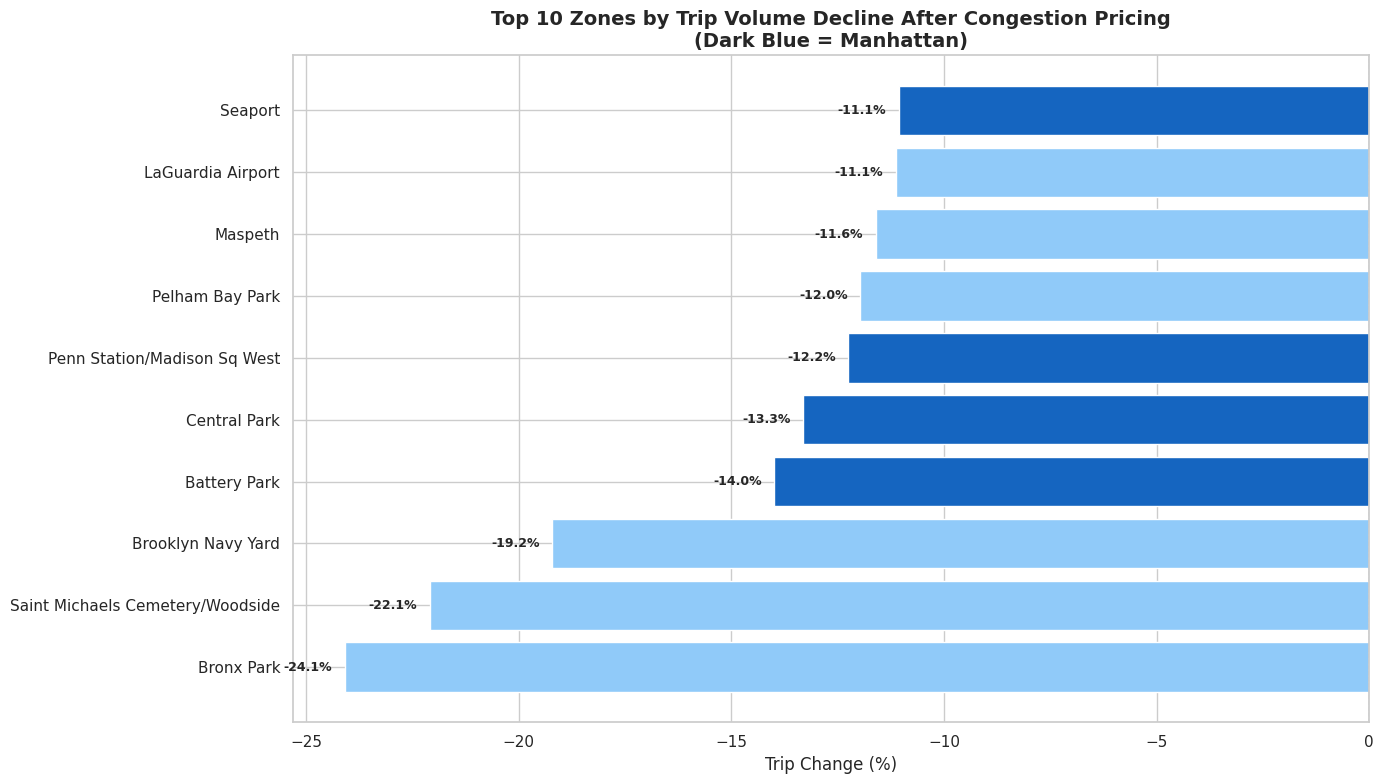

Chart saved


In [8]:
fig, ax = plt.subplots(figsize = (14, 8))

top10 = df_zones.head(10)
colors_zones = [COLOR_BEFORE if b == 'Manhattan' else COLOR_AFTER for b in top10['borough']]

bars = ax.barh(top10['zone'], top10['trip_change_pct'], color = colors_zones, edgecolor = 'white')

ax.set_title('Top 10 Zones by Trip Volume Decline After Congestion Pricing\n(Dark Blue = Manhattan)',
             fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Trip Change (%)')
ax.axvline(x = 0, color = 'black', linewidth = 0.8, linestyle = '--')

for bar, val in zip(bars, top10['trip_change_pct']):
    ax.text(val - 0.3, bar.get_y() + bar.get_height()/2,
           f'{val:.1f}%', ha = 'right', va = 'center', fontweight = 'bold', fontsize = 9)

plt.tight_layout()
plt.savefig('zone_decline.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print("Chart saved")

Bronx Park, Saint Michaels Cemetery/Woodside, and Brooklyn Navy Yard saw the **steepest declines between 19-24%**, suggesting these outer borough destinations saw disproportionate demand drops despite sitting outside the congestion zone. **Battery Park, Penn Station, and Central Park were the hardest hit high-volume Manhattan zones**, reinforcing that both inner and outer borough destinations felt the policy's impact.



---



## **Time of Day Trip Volume**

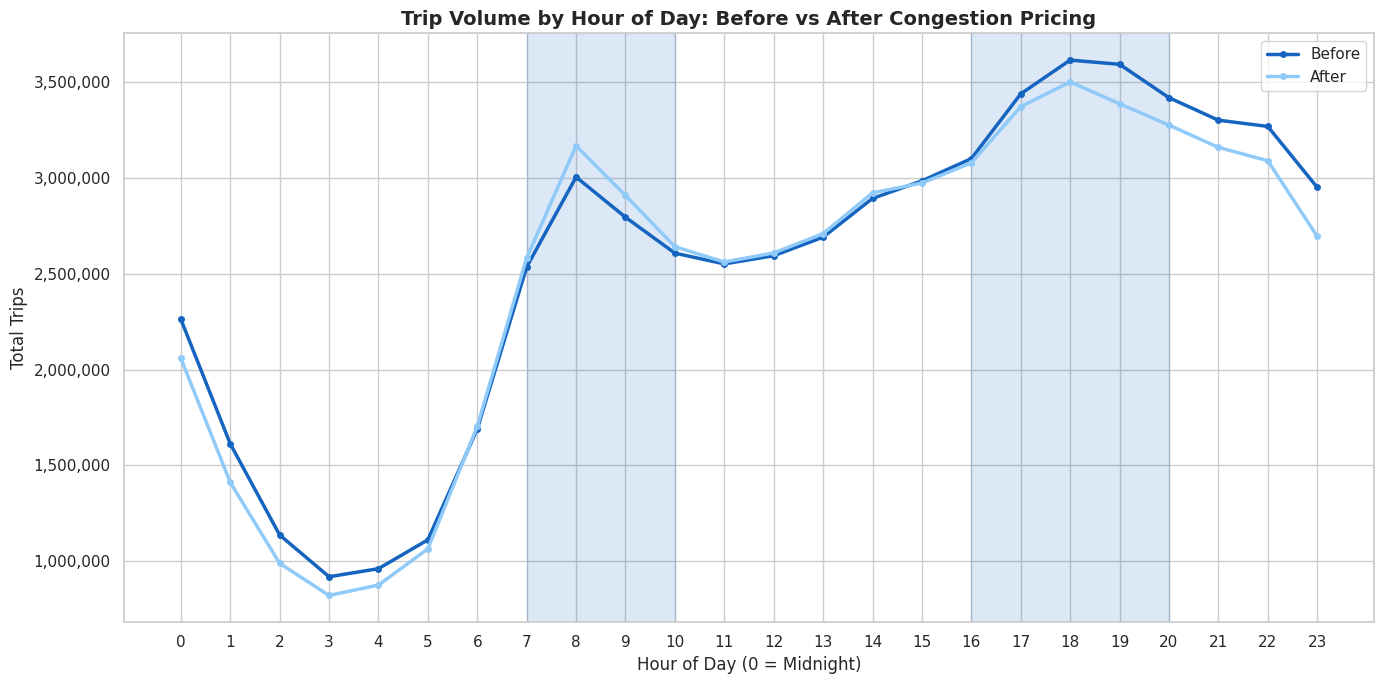

Chart saved


In [9]:
fig, ax = plt.subplots(figsize = (14, 7))

before_tod = df_tod[df_tod['period'] == 'before'].sort_values('hour_of_day')
after_tod = df_tod[df_tod['period'] == 'after'].sort_values('hour_of_day')

ax.plot(before_tod['hour_of_day'], before_tod['total_trips'],
        linewidth = 2.5, color = COLOR_BEFORE, label = 'Before', marker = 'o', markersize = 4)
ax.plot(after_tod['hour_of_day'], after_tod['total_trips'],
        linewidth = 2.5, color = COLOR_AFTER, label = 'After', marker = 'o', markersize = 4)

ax.set_title('Trip Volume by Hour of Day: Before vs After Congestion Pricing',
             fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Hour of Day (0 = Midnight)')
ax.set_ylabel('Total Trips')
ax.set_xticks(range(0, 24))
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax.axvspan(7, 10, alpha=0.15, color=COLOR_BEFORE, label='AM Rush')
ax.axvspan(16, 20, alpha=0.15, color=COLOR_BEFORE, label='PM Rush')

plt.tight_layout()
plt.savefig('time_of_day.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print("Chart saved")

The **before and after curves follow nearly identical shapes throughout the day**, suggesting congestion pricing did not dramatically shift when people travel.

Notably, **trips between 7AM and 10AM are actually higher after implementation**, likely driven by work commuters traveling into the congestion zone who view the $1.50 fee as an acceptable cost for a necessary trip. This suggests price sensitivity is context-dependent: **discretionary trips declined while essential commuter trips held steady or increased.**



---



## **Manhattan Fare & Trip Impact**

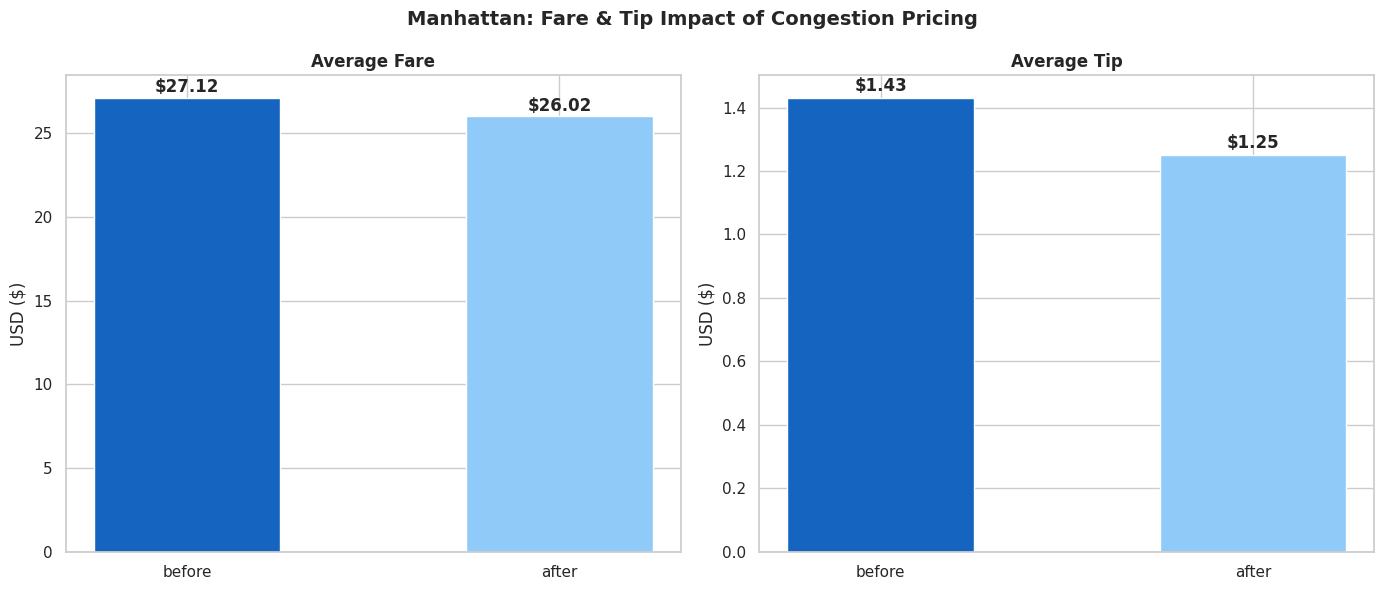

Chart saved


In [10]:
fig, axes = plt.subplots(1, 2, figsize = (14, 6))
fig.suptitle('Manhattan: Fare & Tip Impact of Congestion Pricing',
             fontsize = 14, fontweight = 'bold')

# Avg Fare
axes[0].bar(df_manhattan['period'], df_manhattan['avg_fare'],
            color = [COLOR_BEFORE, COLOR_AFTER], edgecolor = 'white', width = 0.5)
axes[0].set_title('Average Fare', fontweight = 'bold')
axes[0].set_ylabel('USD ($)')
for bar, val in zip(axes[0].patches, df_manhattan['avg_fare']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'${val:.2f}', ha = 'center', va = 'bottom', fontweight = 'bold')

# Avg Tip
axes[1].bar(df_manhattan['period'], df_manhattan['avg_tip'],
            color = [COLOR_BEFORE, COLOR_AFTER], edgecolor = 'white', width = 0.5)
axes[1].set_title('Average Tip', fontweight = 'bold')
axes[1].set_ylabel('USD ($)')
for bar, val in zip(axes[1].patches, df_manhattan['avg_tip']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'${val:.2f}', ha = 'center', va = 'bottom', fontweight = 'bold')

plt.tight_layout()
plt.savefig('manhattan_fare_tip.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print("Chart saved")

Manhattan fares **dropped by $1.10 after congestion pricing, nearly identical to the congestion fee itself**, suggesting riders are taking shorter trips to offset the added cost. Tips declined disproportionately, indicating cost sensitivity beyond the fare alone. Combined, this raises a concern for driver earnings in Manhattan's highest demand zone.



---



## **Conclusion + Next Steps**

This analysis represents **Part 1** of a broader investigation into NYC congestion pricing's
impact on rideshare behavior.

**Part 2** will expand the analysis to a full year comparison (2024 vs 2025), examining:

- Whether the initial behavioral shifts observed here persisted or normalized over time
- Seasonal patterns and how congestion pricing interacts with summer, fall, and holiday travel
- Long-term fare and tipping trends as riders fully adapt to the new pricing environment
- Whether outer boroughs saw delayed impacts not captured in this initial window
- A deeper dive into driver earnings and how congestion pricing affected the supply side

The three-phase behavioral model: **immediate shock → adaptation → new normal**,
will be tested against a full year of data to determine where NYC rideshare currently sits
in that cycle.